<a href="https://colab.research.google.com/github/gabrielramirez2109/proyectomatesegundo/blob/main/figures/graficaspt2/graficas_y_datos_finales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

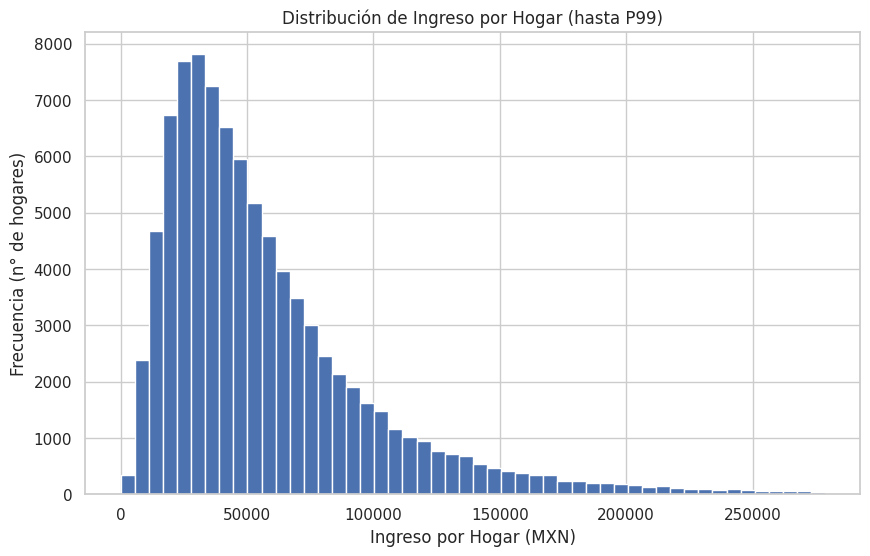

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

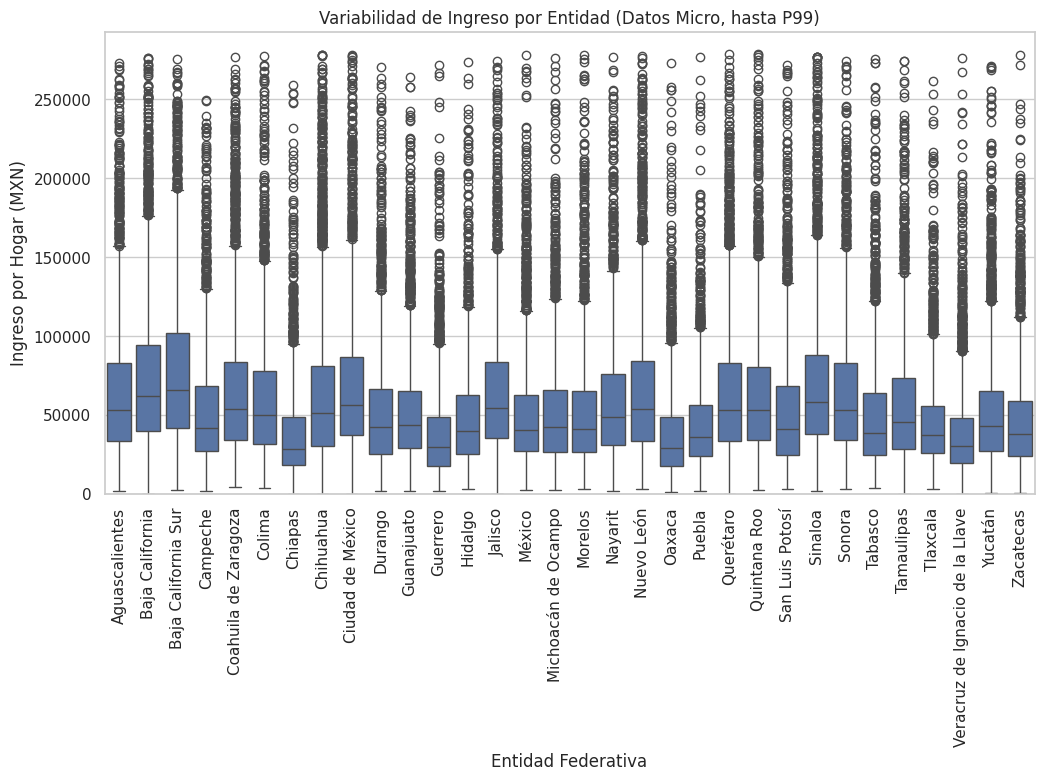

Percentiles de ingreso por hogar:


,Valor,Percentil
0.10,18127.9340,P10
0.25,28385.6875,P25
0.50,46073.6850,P50
0.75,74343.6500,P75
0.90,115839.4470,P90


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

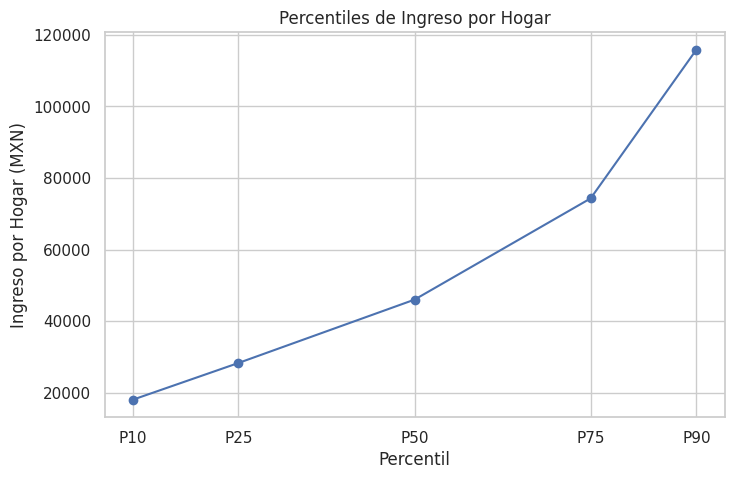

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

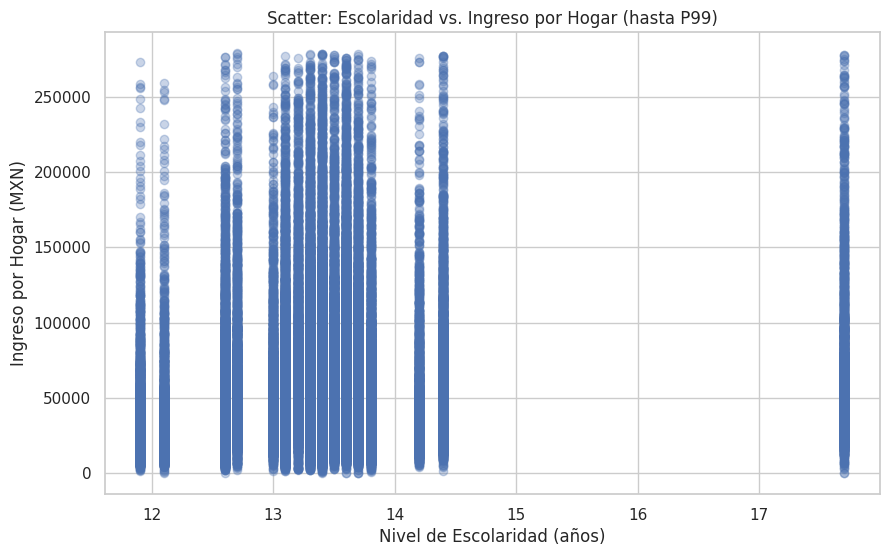

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

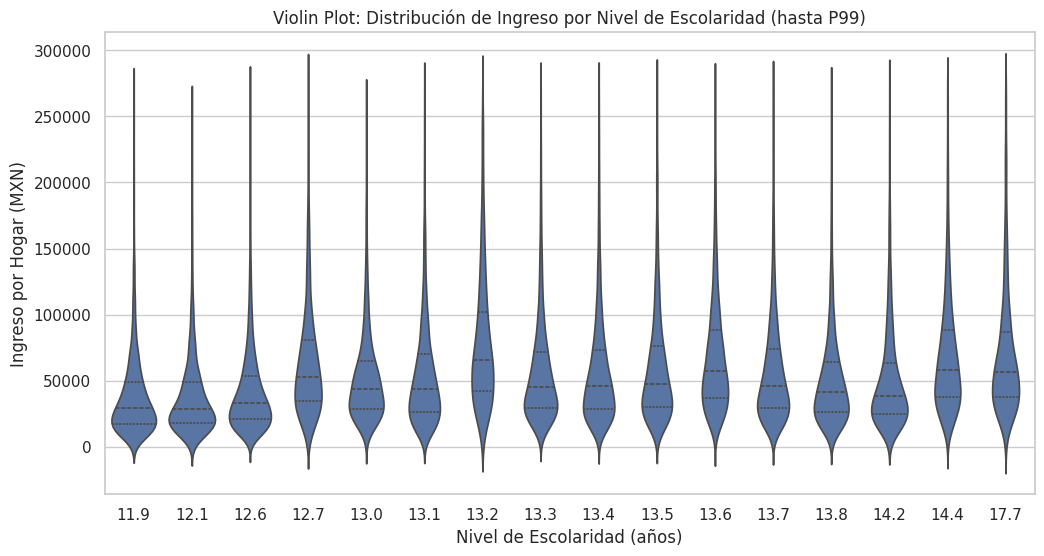

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

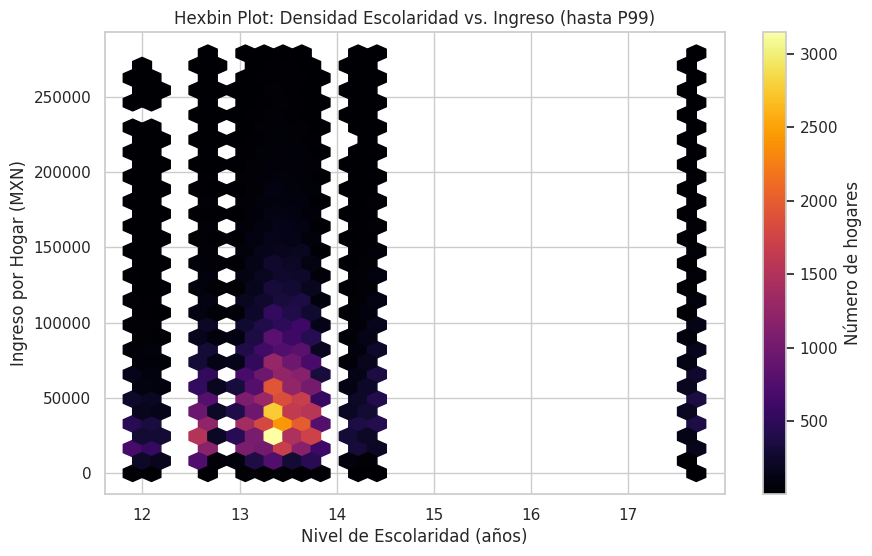

Matriz de correlaciones (hasta P99):


,nivel_escolaridad,ingreso_hogar,pib_millones
nivel_escolaridad,1.000000,0.112306,0.607196
ingreso_hogar,0.112306,1.000000,0.053901
pib_millones,0.607196,0.053901,1.000000


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

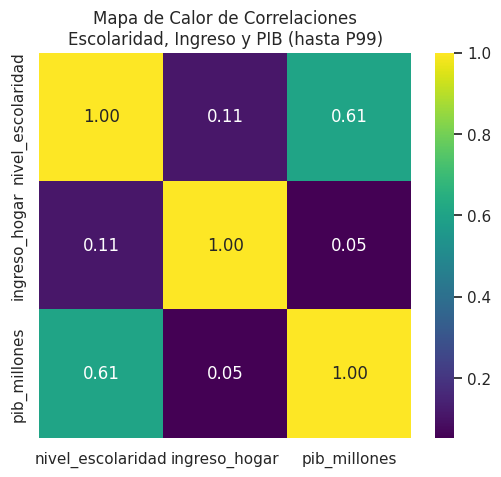

Coeficiente de Gini (Ingreso por Hogar): 0.409


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

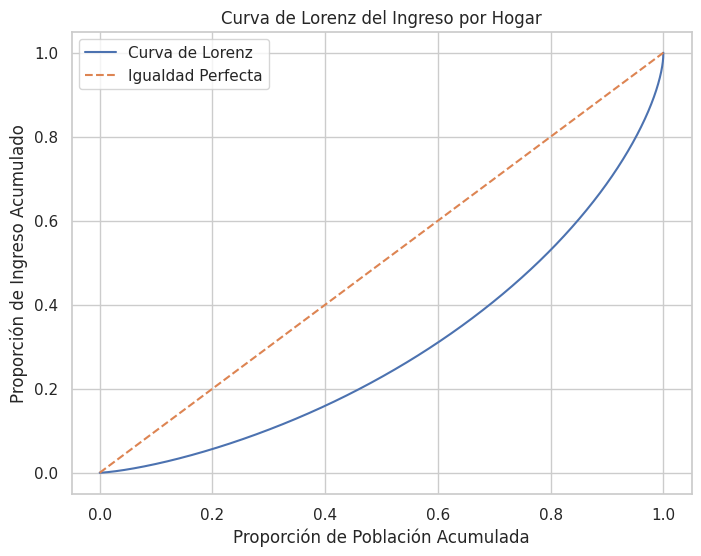

=== Estadísticos Globales ===
Media     : 61,489.96 MXN
Mediana   : 46,073.68 MXN
Varianza  : 6,134,781,006.58
Desv. Est.: 78,324.84 MXN

=== Resumen por Entidad ===


,Media,Mediana,Varianza,Desv_Est
entidad,,,,
Baja California Sur,87776.711830,66968.510,8.447117e+09,91908.200655
Baja California,80340.935805,62690.150,1.709370e+10,130742.866909
Ciudad de México,77909.252414,57196.710,6.890097e+09,83006.608512
Sinaloa,73983.519845,58731.800,1.285151e+10,113364.484830
Chihuahua,73980.632659,51688.500,2.323985e+10,152446.233433
Aguascalientes,73161.576800,54286.000,6.131987e+09,78307.005644
Nuevo León,70860.645246,54175.630,4.364307e+09,66062.898209
Sonora,70544.925243,53728.175,3.925828e+09,62656.424478
Coahuila de Zaragoza,69760.737782,54137.060,4.582218e+09,67692.082635


=== Ratios de Brecha ===
P90 / P10 : 6.39
S80 / S20 : 3.33



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

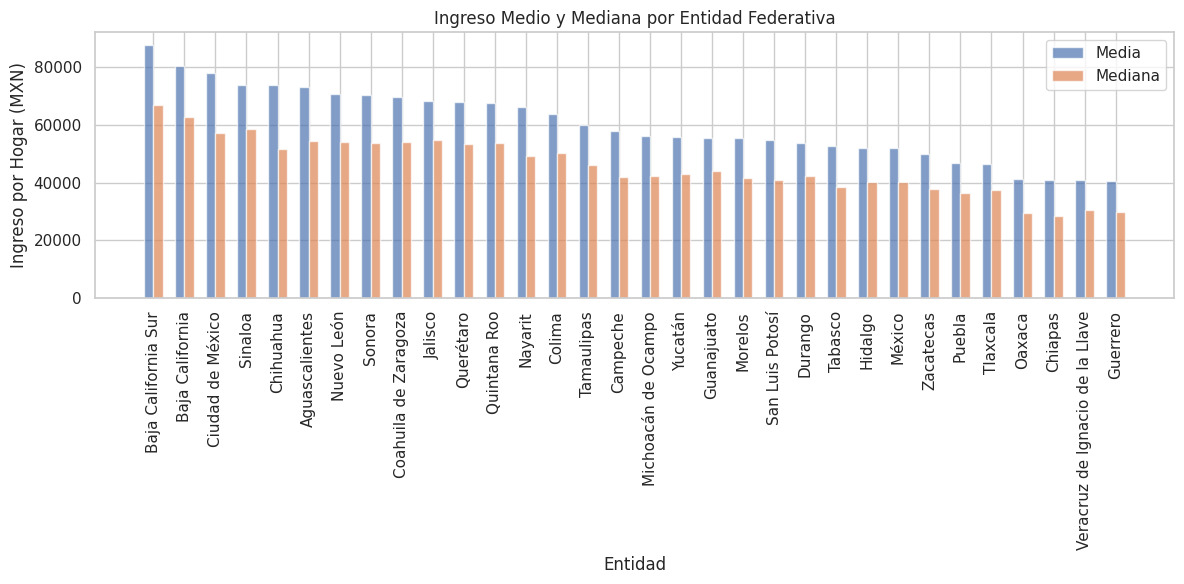

=== Summary Regresión Lineal ===
                            OLS Regression Results                            
Dep. Variable:          ingreso_hogar   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     1139.
Date:                Mon, 09 Jun 2025   Prob (F-statistic):          3.36e-248
Time:                        06:05:55   Log-Likelihood:            -1.0760e+06
No. Observations:               89200   AIC:                         2.152e+06
Df Residuals:                   89198   BIC:                         2.152e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const

<ipython-input-73-196b8bc8c916>:200: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'label':f"y={model.params[1]:.2f}x+{model.params[0]:.0f}"})


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

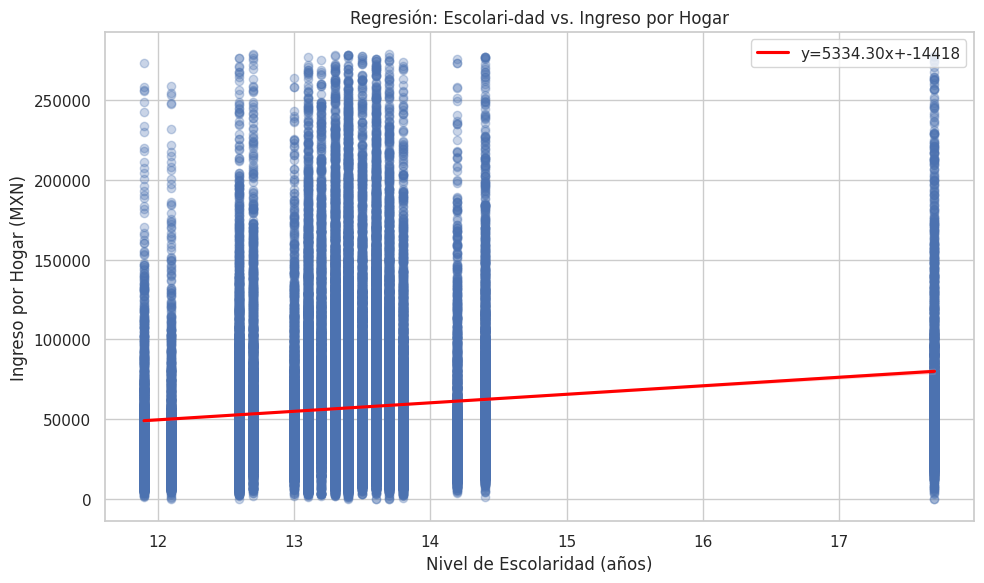

In [ ]:
!pip install seaborn statsmodels --quiet

import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from google.colab import files

sns.set(style="whitegrid")


df_base  = pd.read_csv('base_final_combinada.csv')
df_micro = pd.read_csv('concentradohogarbueno.csv')

req_base = {'desc_ent','ing_cor','escolaridad_promedio','pib_millones'}
if not req_base.issubset(df_base.columns):
    raise KeyError(f"Faltan columnas en base_final_combinada.csv: {req_base - set(df_base.columns)}")
df_base = df_base.rename(columns={
    'desc_ent': 'entidad',
    'ing_cor': 'ingreso_promedio',
    'escolaridad_promedio': 'nivel_escolaridad',
    'pib_millones': 'pib_millones'
})

req_micro = {'desc_ent','ing_cor'}
if not req_micro.issubset(df_micro.columns):
    raise KeyError(f"Faltan columnas en concentradohogarbueno.csv: {req_micro - set(df_micro.columns)}")
df_micro = df_micro.rename(columns={
    'desc_ent': 'entidad',
    'ing_cor': 'ingreso_hogar'
})


df = df_micro.merge(
    df_base[['entidad','nivel_escolaridad','pib_millones']],
    on='entidad',
    how='left'
)


limite_99 = df['ingreso_hogar'].quantile(0.99)
df_filt   = df[df['ingreso_hogar'] <= limite_99].copy()


def save(name):
    plt.savefig(name, dpi=300, bbox_inches='tight')
    files.download(name)


plt.figure(figsize=(10,6))
plt.hist(df_filt['ingreso_hogar'], bins=50)
plt.title('Distribución de Ingreso por Hogar (hasta P99)')
plt.xlabel('Ingreso por Hogar (MXN)')
plt.ylabel('Frecuencia (n° de hogares)')
save('hist_ingreso_hogar.png')
plt.show()


plt.figure(figsize=(12,6))
sns.boxplot(x='entidad', y='ingreso_hogar', data=df_filt)
plt.xticks(rotation=90)
plt.title('Variabilidad de Ingreso por Entidad (Datos Micro, hasta P99)')
plt.xlabel('Entidad Federativa')
plt.ylabel('Ingreso por Hogar (MXN)')
plt.ylim(0, limite_99*1.05)
save('boxplot_hogar_entidad.png')
plt.show()


percentiles = [0.10,0.25,0.50,0.75,0.90]
pct_vals = df['ingreso_hogar'].quantile(percentiles).to_frame('Valor')
pct_vals['Percentil'] = ['P10','P25','P50','P75','P90']
print("Percentiles de ingreso por hogar:")
display(pct_vals)

plt.figure(figsize=(8,5))
plt.plot(percentiles, pct_vals['Valor'], marker='o')
plt.title('Percentiles de Ingreso por Hogar')
plt.xlabel('Percentil')
plt.ylabel('Ingreso por Hogar (MXN)')
plt.xticks(percentiles, pct_vals['Percentil'])
save('percentiles_hogar.png')
plt.show()


plt.figure(figsize=(10,6))
plt.scatter(df_filt['nivel_escolaridad'], df_filt['ingreso_hogar'], alpha=0.3)
plt.title('Scatter: Escolaridad vs. Ingreso por Hogar (hasta P99)')
plt.xlabel('Nivel de Escolaridad (años)')
plt.ylabel('Ingreso por Hogar (MXN)')
save('scatter_escolaridad_hogar.png')
plt.show()


plt.figure(figsize=(12,6))
sns.violinplot(x='nivel_escolaridad', y='ingreso_hogar',
               data=df_filt, inner='quartile')
plt.title('Violin Plot: Distribución de Ingreso por Nivel de Escolaridad (hasta P99)')
plt.xlabel('Nivel de Escolaridad (años)')
plt.ylabel('Ingreso por Hogar (MXN)')
save('violin_escolaridad_hogar.png')
plt.show()


plt.figure(figsize=(10,6))
hb = plt.hexbin(df_filt['nivel_escolaridad'], df_filt['ingreso_hogar'],
                gridsize=30, mincnt=1, cmap='inferno')
plt.colorbar(hb, label='Número de hogares')
plt.title('Hexbin Plot: Densidad Escolaridad vs. Ingreso (hasta P99)')
plt.xlabel('Nivel de Escolaridad (años)')
plt.ylabel('Ingreso por Hogar (MXN)')
save('hexbin_escolaridad_hogar.png')
plt.show()


corr = df_filt[['nivel_escolaridad','ingreso_hogar','pib_millones']].corr()
print("Matriz de correlaciones (hasta P99):")
display(corr)
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='viridis')
plt.title('Mapa de Calor de Correlaciones\nEscolaridad, Ingreso y PIB (hasta P99)')
save('heatmap_hogar_correlacion.png')
plt.show()


def gini(x):
    x = x.dropna().sort_values().values
    n = len(x)
    idx = np.arange(1, n+1)
    return (np.sum((2*idx - n - 1) * x)) / (n * np.sum(x))

print(f"Coeficiente de Gini (Ingreso por Hogar): {gini(df['ingreso_hogar']):.3f}")

inc = df['ingreso_hogar'].dropna().sort_values().values
cum = np.cumsum(inc) / inc.sum()
pop = np.arange(1, len(inc)+1) / len(inc)
plt.figure(figsize=(8,6))
plt.plot(pop, cum, label='Curva de Lorenz')
plt.plot([0,1],[0,1],'--', label='Igualdad Perfecta')
plt.title('Curva de Lorenz del Ingreso por Hogar')
plt.xlabel('Proporción de Población Acumulada')
plt.ylabel('Proporción de Ingreso Acumulado')
plt.legend()
save('lorenz_hogar.png')
plt.show()


media    = df['ingreso_hogar'].mean()
mediana  = df['ingreso_hogar'].median()
varianza = df['ingreso_hogar'].var()
desvest  = df['ingreso_hogar'].std()
print("=== Estadísticos Globales ===")
print(f"Media     : {media:,.2f} MXN")
print(f"Mediana   : {mediana:,.2f} MXN")
print(f"Varianza  : {varianza:,.2f}")
print(f"Desv. Est.: {desvest:,.2f} MXN\n")


res_estado = df.groupby('entidad')['ingreso_hogar'].agg(
    Media='mean', Mediana='median', Varianza='var', Desv_Est='std'
).sort_values('Media', ascending=False)
print("=== Resumen por Entidad ===")
display(res_estado)


p10, p90 = df['ingreso_hogar'].quantile([0.10,0.90])
s20, s80 = df['ingreso_hogar'].quantile([0.20,0.80])
print("=== Ratios de Brecha ===")
print(f"P90 / P10 : {p90/p10:.2f}")
print(f"S80 / S20 : {s80/s20:.2f}\n")


plt.figure(figsize=(12,6))
x = np.arange(len(res_estado))
plt.bar(x-0.15, res_estado['Media'],  width=0.3, label='Media',   alpha=0.7)
plt.bar(x+0.15, res_estado['Mediana'],width=0.3, label='Mediana', alpha=0.7)
plt.xticks(x, res_estado.index, rotation=90)
plt.title('Ingreso Medio y Mediana por Entidad Federativa')
plt.xlabel('Entidad')
plt.ylabel('Ingreso por Hogar (MXN)')
plt.legend()
plt.tight_layout()
plt.savefig('barras_media_mediana_estado.png', dpi=300)
files.download('barras_media_mediana_estado.png')
plt.show()


X = sm.add_constant(df_filt['nivel_escolaridad'])
y = df_filt['ingreso_hogar']
model = sm.OLS(y, X).fit()
print("=== Summary Regresión Lineal ===")
print(model.summary())

plt.figure(figsize=(10,6))
sns.regplot(x='nivel_escolaridad', y='ingreso_hogar', data=df_filt,
            scatter_kws={'alpha':0.3},
            line_kws={'color':'red',
                      'label':f"y={model.params[1]:.2f}x+{model.params[0]:.0f}"})
plt.title('Regresión: Escolari­dad vs. Ingreso por Hogar')
plt.xlabel('Nivel de Escolaridad (años)')
plt.ylabel('Ingreso por Hogar (MXN)')
plt.legend()
plt.tight_layout()
plt.savefig('regresion_escolaridad_ingreso.png', dpi=300)
files.download('regresion_escolaridad_ingreso.png')
plt.show()




=== Estadísticos Globales: PIB per Cápita ===
Media    : 758,543.18 millones MXN
Mediana  : 524,583.64 millones MXN
Varianza : 540,193,612,401.35
Desv. Est: 734,978.65 millones MXN



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

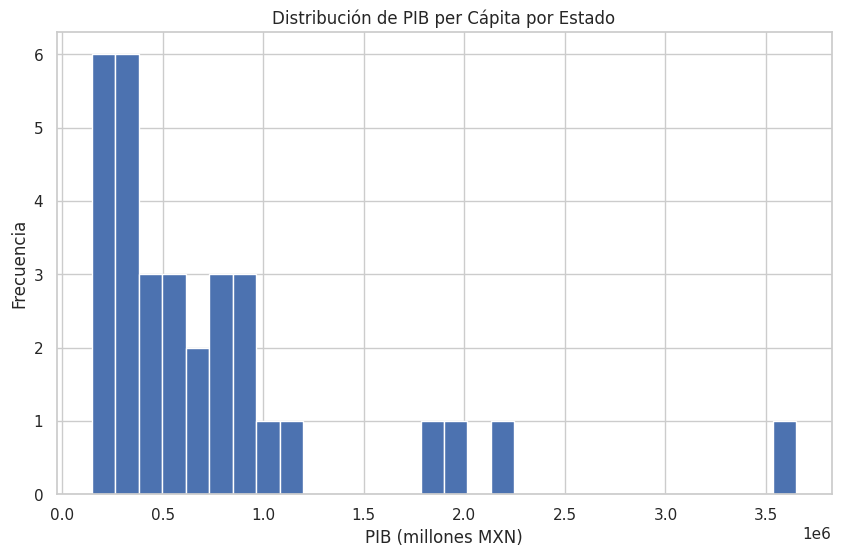

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

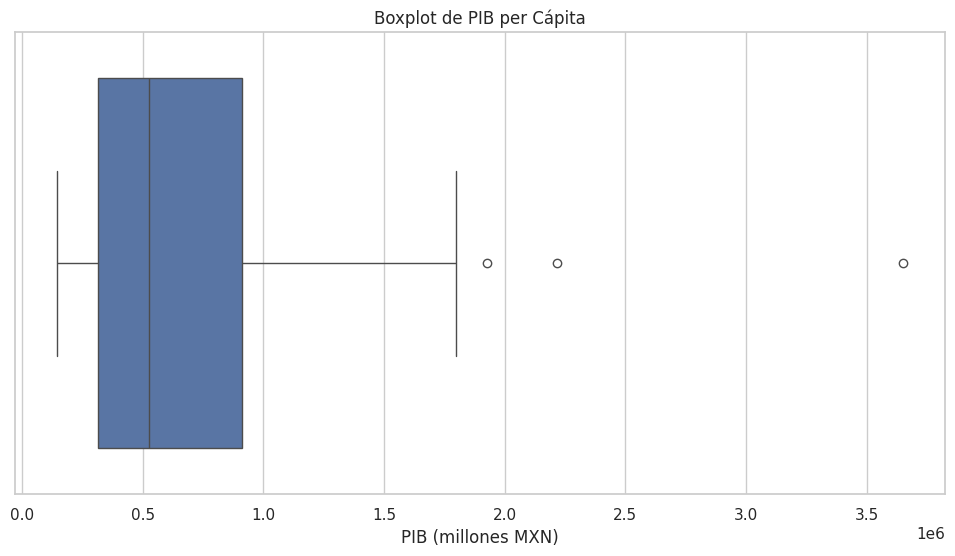

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

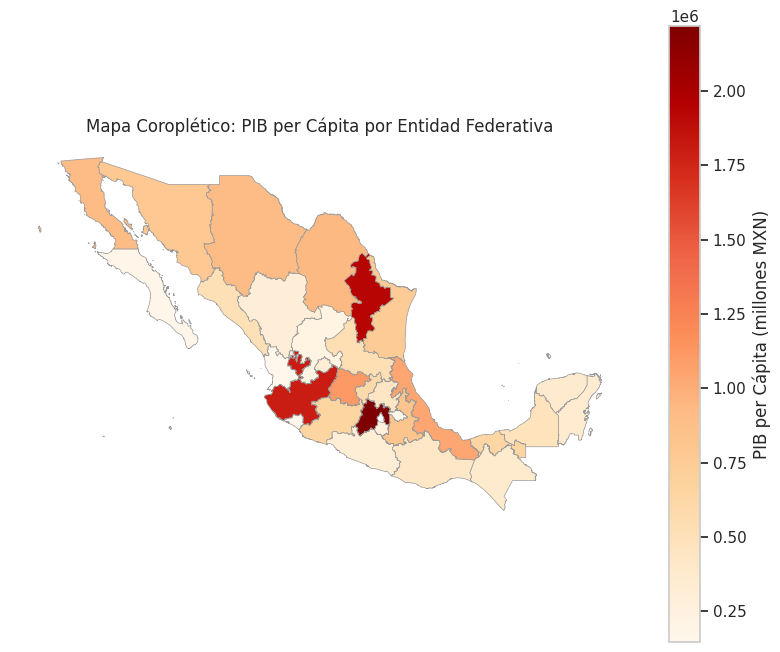

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

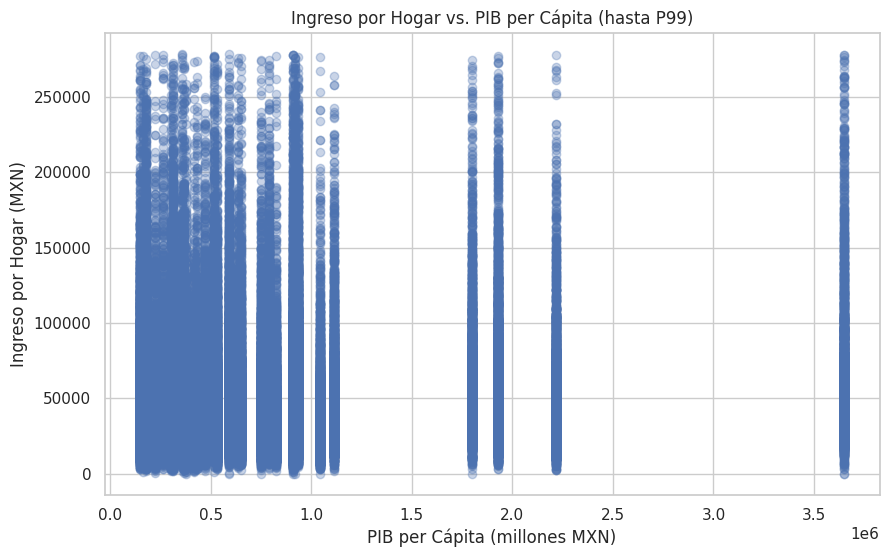

=== Resultados Regresión OLS: Ingreso vs. PIB ===
                            OLS Regression Results                            
Dep. Variable:          ingreso_hogar   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     259.9
Date:                Mon, 09 Jun 2025   Prob (F-statistic):           2.18e-58
Time:                        06:06:18   Log-Likelihood:            -1.0764e+06
No. Observations:               89200   AIC:                         2.153e+06
Df Residuals:                   89198   BIC:                         2.153e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

<ipython-input-74-5c37792c2ac9>:112: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'label':f"y={model_pib.params[1]:.2f}·x+{model_pib.params[0]:.0f}"}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

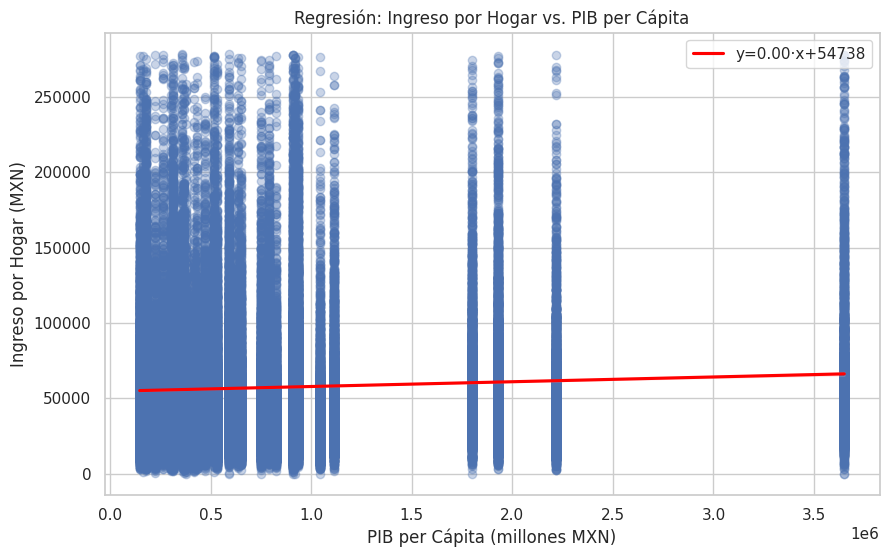


=== Estadísticos por Cuartil de Ingreso ===
                 Media     Mediana      Varianza       Desv_Est
quartil                                                        
Q1        19245.934472   20054.210  3.723806e+07    6102.299756
Q2        36816.773825   36601.790  2.586014e+07    5085.286737
Q3        58593.704986   57803.840  6.492953e+07    8057.885964
Q4       131302.210824  104777.605  1.713561e+10  130903.073372

Diferencia P75 - P25 : 45,957.96 MXN
Ratio P90 / P10     : 6.39


<ipython-input-74-5c37792c2ac9>:123: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = df.groupby('quartil')['ingreso_hogar'].agg(


In [ ]:

!pip install seaborn statsmodels geopandas --quiet


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import statsmodels.api as sm


try:
    from google.colab import files
    def save_and_download(name):
        plt.savefig(name, dpi=300, bbox_inches='tight')
        files.download(name)
except ImportError:
    def save_and_download(name):
        plt.savefig(name, dpi=300, bbox_inches='tight')
        print(f"[OK] Figura guardada como {name}")

sns.set(style="whitegrid")

# Carga de datos
df_base = pd.read_csv('base_final_combinada.csv').rename(columns={
    'desc_ent': 'entidad',
    'ing_cor': 'ingreso_promedio',
    'escolaridad_promedio': 'nivel_escolaridad',
    'pib_millones': 'pib_millones'
})
df_micro = pd.read_csv('concentradohogarbueno.csv').rename(columns={
    'desc_ent': 'entidad',
    'ing_cor': 'ingreso_hogar'
})
¿
df = df_micro.merge(df_base[['entidad','pib_millones']], on='entidad', how='left')


pib = df_base['pib_millones'].dropna()
print("=== Estadísticos Globales: PIB per Cápita ===")
print(f"Media    : {pib.mean():,.2f} millones MXN")
print(f"Mediana  : {pib.median():,.2f} millones MXN")
print(f"Varianza : {pib.var():,.2f}")
print(f"Desv. Est: {pib.std():,.2f} millones MXN\n")


plt.figure(figsize=(10,6))
plt.hist(pib, bins=30)
plt.title('Distribución de PIB per Cápita por Estado')
plt.xlabel('PIB (millones MXN)')
plt.ylabel('Frecuencia')
save_and_download('hist_pib.png')
plt.show()

plt.figure(figsize=(12,6))
sns.boxplot(x=pib)
plt.title('Boxplot de PIB per Cápita')
plt.xlabel('PIB (millones MXN)')
save_and_download('boxplot_pib.png')
plt.show()


limite_99 = df['ingreso_hogar'].quantile(0.99)
df_filt = df[df['ingreso_hogar'] <= limite_99].copy()

plt.figure(figsize=(10,6))
plt.scatter(df_filt['pib_millones'], df_filt['ingreso_hogar'], alpha=0.3)
plt.title('Ingreso por Hogar vs. PIB per Cápita (hasta P99)')
plt.xlabel('PIB per Cápita (millones MXN)')
plt.ylabel('Ingreso por Hogar (MXN)')
save_and_download('scatter_ingreso_pib.png')
plt.show()


X = sm.add_constant(df_filt['pib_millones'])
y = df_filt['ingreso_hogar']
model_pib = sm.OLS(y, X).fit()
print("=== Resultados Regresión OLS: Ingreso vs. PIB ===")
print(model_pib.summary())


plt.figure(figsize=(10,6))
sns.regplot(
    x='pib_millones', y='ingreso_hogar',
    data=df_filt,
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red',
              'label':f"y={model_pib.params[1]:.2f}·x+{model_pib.params[0]:.0f}"}
)
plt.title('Regresión: Ingreso por Hogar vs. PIB per Cápita')
plt.xlabel('PIB per Cápita (millones MXN)')
plt.ylabel('Ingreso por Hogar (MXN)')
plt.legend()
save_and_download('regresion_ingreso_pib.png')
plt.show()

df['quartil'] = pd.qcut(df['ingreso_hogar'], q=4, labels=['Q1','Q2','Q3','Q4'])
group_stats = df.groupby('quartil')['ingreso_hogar'].agg(
    Media='mean', Mediana='median', Varianza='var', Desv_Est='std'
)
print("\n=== Estadísticos por Cuartil de Ingreso ===")
print(group_stats.to_string())


p25, p75, p10, p90 = df['ingreso_hogar'].quantile([0.25,0.75,0.10,0.90])
print(f"\nDiferencia P75 - P25 : {p75-p25:,.2f} MXN")
print(f"Ratio P90 / P10     : {p90/p10:.2f}")



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 4.1 MB/s eta 0:00:00


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

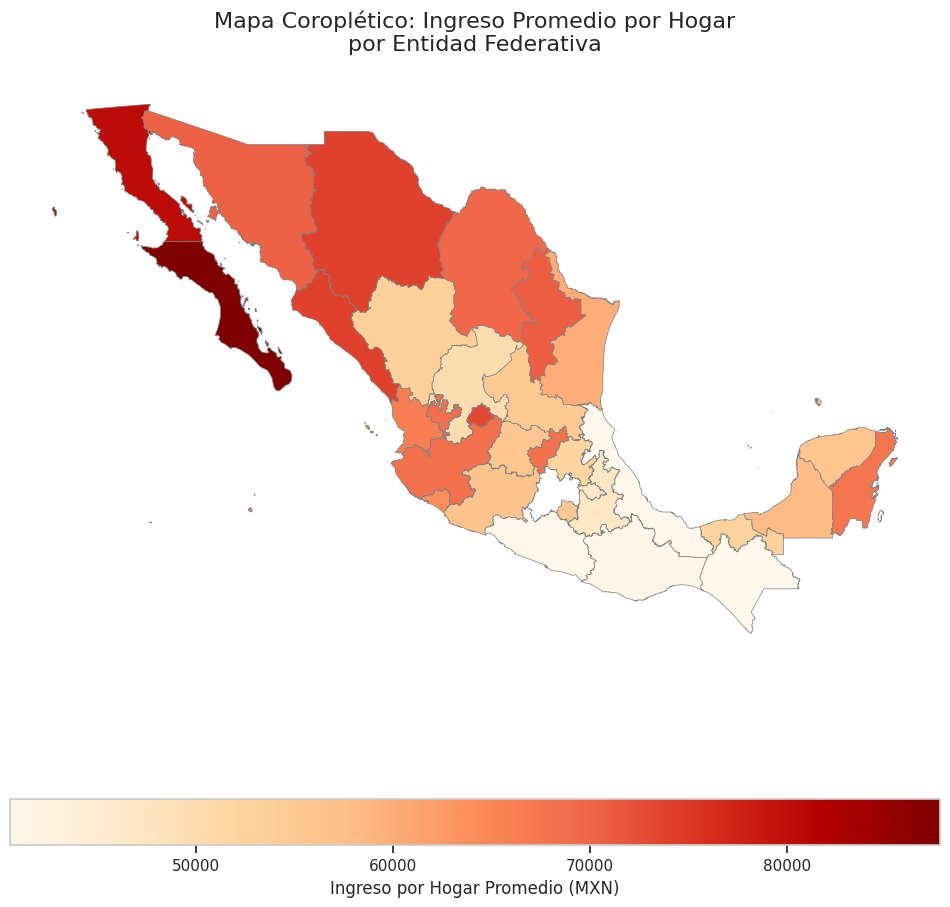

In [ ]:
!pip install geopandas unidecode

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from unidecode import unidecode


df = pd.read_csv('base_final_combinada.csv')
estados = gpd.read_file('mexico_states.geojson')




df['desc_ent'] = df['desc_ent'].replace({'México': 'Estado de México'})

}
df['desc_norm'] = df['desc_ent'].apply(lambda x: unidecode(x).lower())
estados['name']    = estados['name'].str.strip()
estados['name_norm'] = estados['name'].apply(lambda x: unidecode(x).lower())


choropleth = estados.merge(
    df[['desc_ent', 'desc_norm', 'ing_cor']],
    left_on='name_norm',
    right_on='desc_norm',
    how='left'
)


fig, ax = plt.subplots(1, 1, figsize=(12, 12))

choropleth.plot(
    column='ing_cor',
    cmap='OrRd',
    linewidth=0.5,
    edgecolor='gray',
    legend=True,
    legend_kwds={
      'label': "Ingreso por Hogar Promedio (MXN)",
      'orientation': "horizontal"
    },
    ax=ax
)

ax.set_title(
    "Mapa Coroplético: Ingreso Promedio por Hogar\npor Entidad Federativa",
    fontsize=16, pad=20
)
ax.axis('off')


fig.savefig('mapa_coropletico.png', dpi=300, bbox_inches='tight')

from google.colab import files
files.download('mapa_coropletico.png')
